In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier



In [2]:
df = pd.read_csv('plant_health_data.csv')

In [70]:
df

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status,Week,Plant_Health_Status_Encoded
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress,2024-09-30,2
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress,2024-09-30,2
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress,2024-09-30,2
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress,2024-09-30,2
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress,2024-09-30,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024-11-01 04:54:53.493508,10,29.665780,27.605285,15.381699,54.668196,650.536854,5.715289,29.993107,14.914470,21.560747,24.273224,0.714553,Moderate Stress,2024-10-28,1
1196,2024-11-01 10:54:53.493508,10,15.490782,22.108112,15.221033,61.243143,768.760787,5.958957,45.258678,25.216248,31.940717,30.930676,1.448029,High Stress,2024-10-28,2
1197,2024-11-01 16:54:53.493508,10,23.495723,21.680240,15.499764,40.693671,293.643366,7.419157,38.351189,48.656078,28.473233,38.324484,0.880019,Moderate Stress,2024-10-28,1
1198,2024-11-01 22:54:53.493508,10,30.971675,23.019488,21.934918,41.387107,492.952014,5.855767,49.402550,23.843971,19.750042,46.027529,0.344597,Healthy,2024-10-28,0


In [3]:
# Display basic information about the dataset
print("Shape of the dataset:", df.shape)
display(df.head())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
display(df.describe().T)

Shape of the dataset: (1200, 14)


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   object 
 1   Plant_ID                1200 non-null   int64  
 2   Soil_Moisture           1200 non-null   float64
 3   Ambient_Temperature     1200 non-null   float64
 4   Soil_Temperature        1200 non-null   float64
 5   Humidity                1200 non-null   float64
 6   Light_Intensity         1200 non-null   float64
 7   Soil_pH                 1200 non-null   float64
 8   Nitrogen_Level          1200 non-null   float64
 9   Phosphorus_Level        1200 non-null   float64
 10  Potassium_Level         1200 non-null   float64
 11  Chlorophyll_Content     1200 non-null   float64
 12  Electrochemical_Signal  1200 non-null   float64
 13  Plant_Health_Status     1200 non-null   object 
dtypes: float64(11), in

,count,mean,std,min,25%,50%,75%,max
Plant_ID,1200.0,5.500000,2.873479,1.000000,3.000000,5.500000,8.000000,10.000000
Soil_Moisture,1200.0,25.106918,8.677725,10.000724,17.131893,25.168333,32.370231,39.993164
Ambient_Temperature,1200.0,23.999130,3.441561,18.001993,21.101766,23.889044,27.042634,29.990886
Soil_Temperature,1200.0,19.957794,2.932073,15.003710,17.353027,19.911473,22.596851,24.995929
Humidity,1200.0,54.853165,8.784916,40.028758,47.019694,54.692069,62.451053,69.968871
Light_Intensity,1200.0,612.637265,228.318853,200.615482,416.878983,617.240221,811.474690,999.856262
Soil_pH,1200.0,6.524102,0.581755,5.507392,6.026042,6.540524,7.030039,7.497823
Nitrogen_Level,1200.0,30.106751,11.514396,10.003650,20.249774,30.138590,40.184737,49.951136
Phosphorus_Level,1200.0,30.264484,11.466846,10.017690,20.894445,30.019385,40.131459,49.980700
Potassium_Level,1200.0,30.112088,11.668085,10.000606,19.585561,30.495054,40.108296,49.981945


In [4]:
print("\nUnique Values in Each Column:")
print(df.nunique())


Unique Values in Each Column:
Timestamp                 1200
Plant_ID                    10
Soil_Moisture             1200
Ambient_Temperature       1200
Soil_Temperature          1200
Humidity                  1200
Light_Intensity           1200
Soil_pH                   1200
Nitrogen_Level            1200
Phosphorus_Level          1200
Potassium_Level           1200
Chlorophyll_Content       1200
Electrochemical_Signal    1200
Plant_Health_Status          3
dtype: int64


In [5]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("\nNumerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)


Numerical Columns: ['Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']
Categorical Columns: ['Timestamp', 'Plant_Health_Status']


In [6]:
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {df[col].unique()}")


Column: Timestamp
Unique Values: ['2024-10-03 10:54:53.407995' '2024-10-03 16:54:53.407995'
 '2024-10-03 22:54:53.407995' ... '2024-11-01 16:54:53.493508'
 '2024-11-01 22:54:53.493508' '2024-11-02 04:54:53.493508']

Column: Plant_Health_Status
Unique Values: ['High Stress' 'Moderate Stress' 'Healthy']


C:\Users\salja\AppData\Local\Temp\ipykernel_14388\1320474038.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=df, palette='muted')


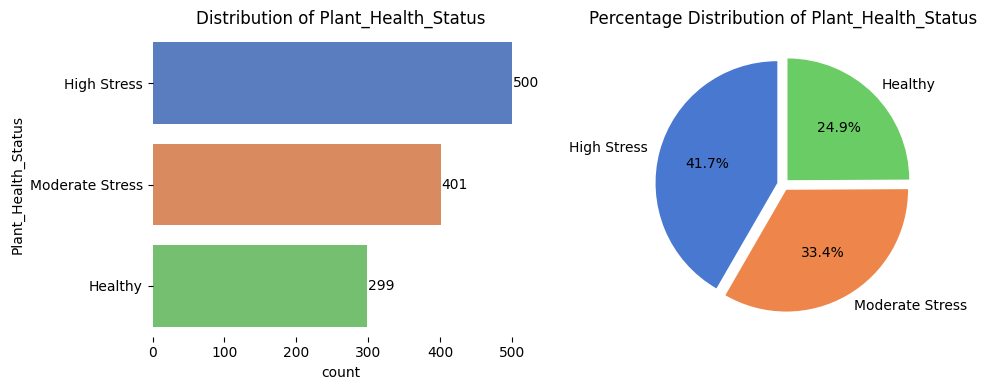

In [7]:
column_name = 'Plant_Health_Status'
plt.figure(figsize=(10, 4))

# First subplot: Count plot
plt.subplot(1, 2, 1)
sns.countplot(y=column_name, data=df, palette='muted')  
plt.title(f'Distribution of {column_name}')

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='center', va='center', xytext=(10, 0), textcoords='offset points')

sns.despine(left=True, bottom=True)

# Second subplot: Pie chart
plt.subplot(1, 2, 2)
df[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90, explode=[0.05]*df[column_name].nunique())
plt.title(f'Percentage Distribution of {column_name}')
plt.ylabel('')  

plt.tight_layout()
plt.show()

In [8]:
# Find the earliest and latest timestamps
start_date = pd.to_datetime(df['Timestamp']).min()
end_date = pd.to_datetime(df['Timestamp']).max()

print("Start Date:", start_date)
print("End Date:", end_date)

Start Date: 2024-10-03 10:54:53.407995
End Date: 2024-11-02 04:54:53.493508


In [9]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Check time differences between consecutive entries
time_diffs = df['Timestamp'].diff().value_counts()

print("Most common time differences:")
print(time_diffs.head(10))

Most common time differences:
Timestamp
0 days 06:00:00              1190
-30 days +06:00:00.005996       2
-30 days +06:00:00.008994       2
-30 days +06:00:00.006996       2
-30 days +06:00:00.018556       1
-30 days +06:00:00.012991       1
-30 days +06:00:00.009994       1
Name: count, dtype: int64


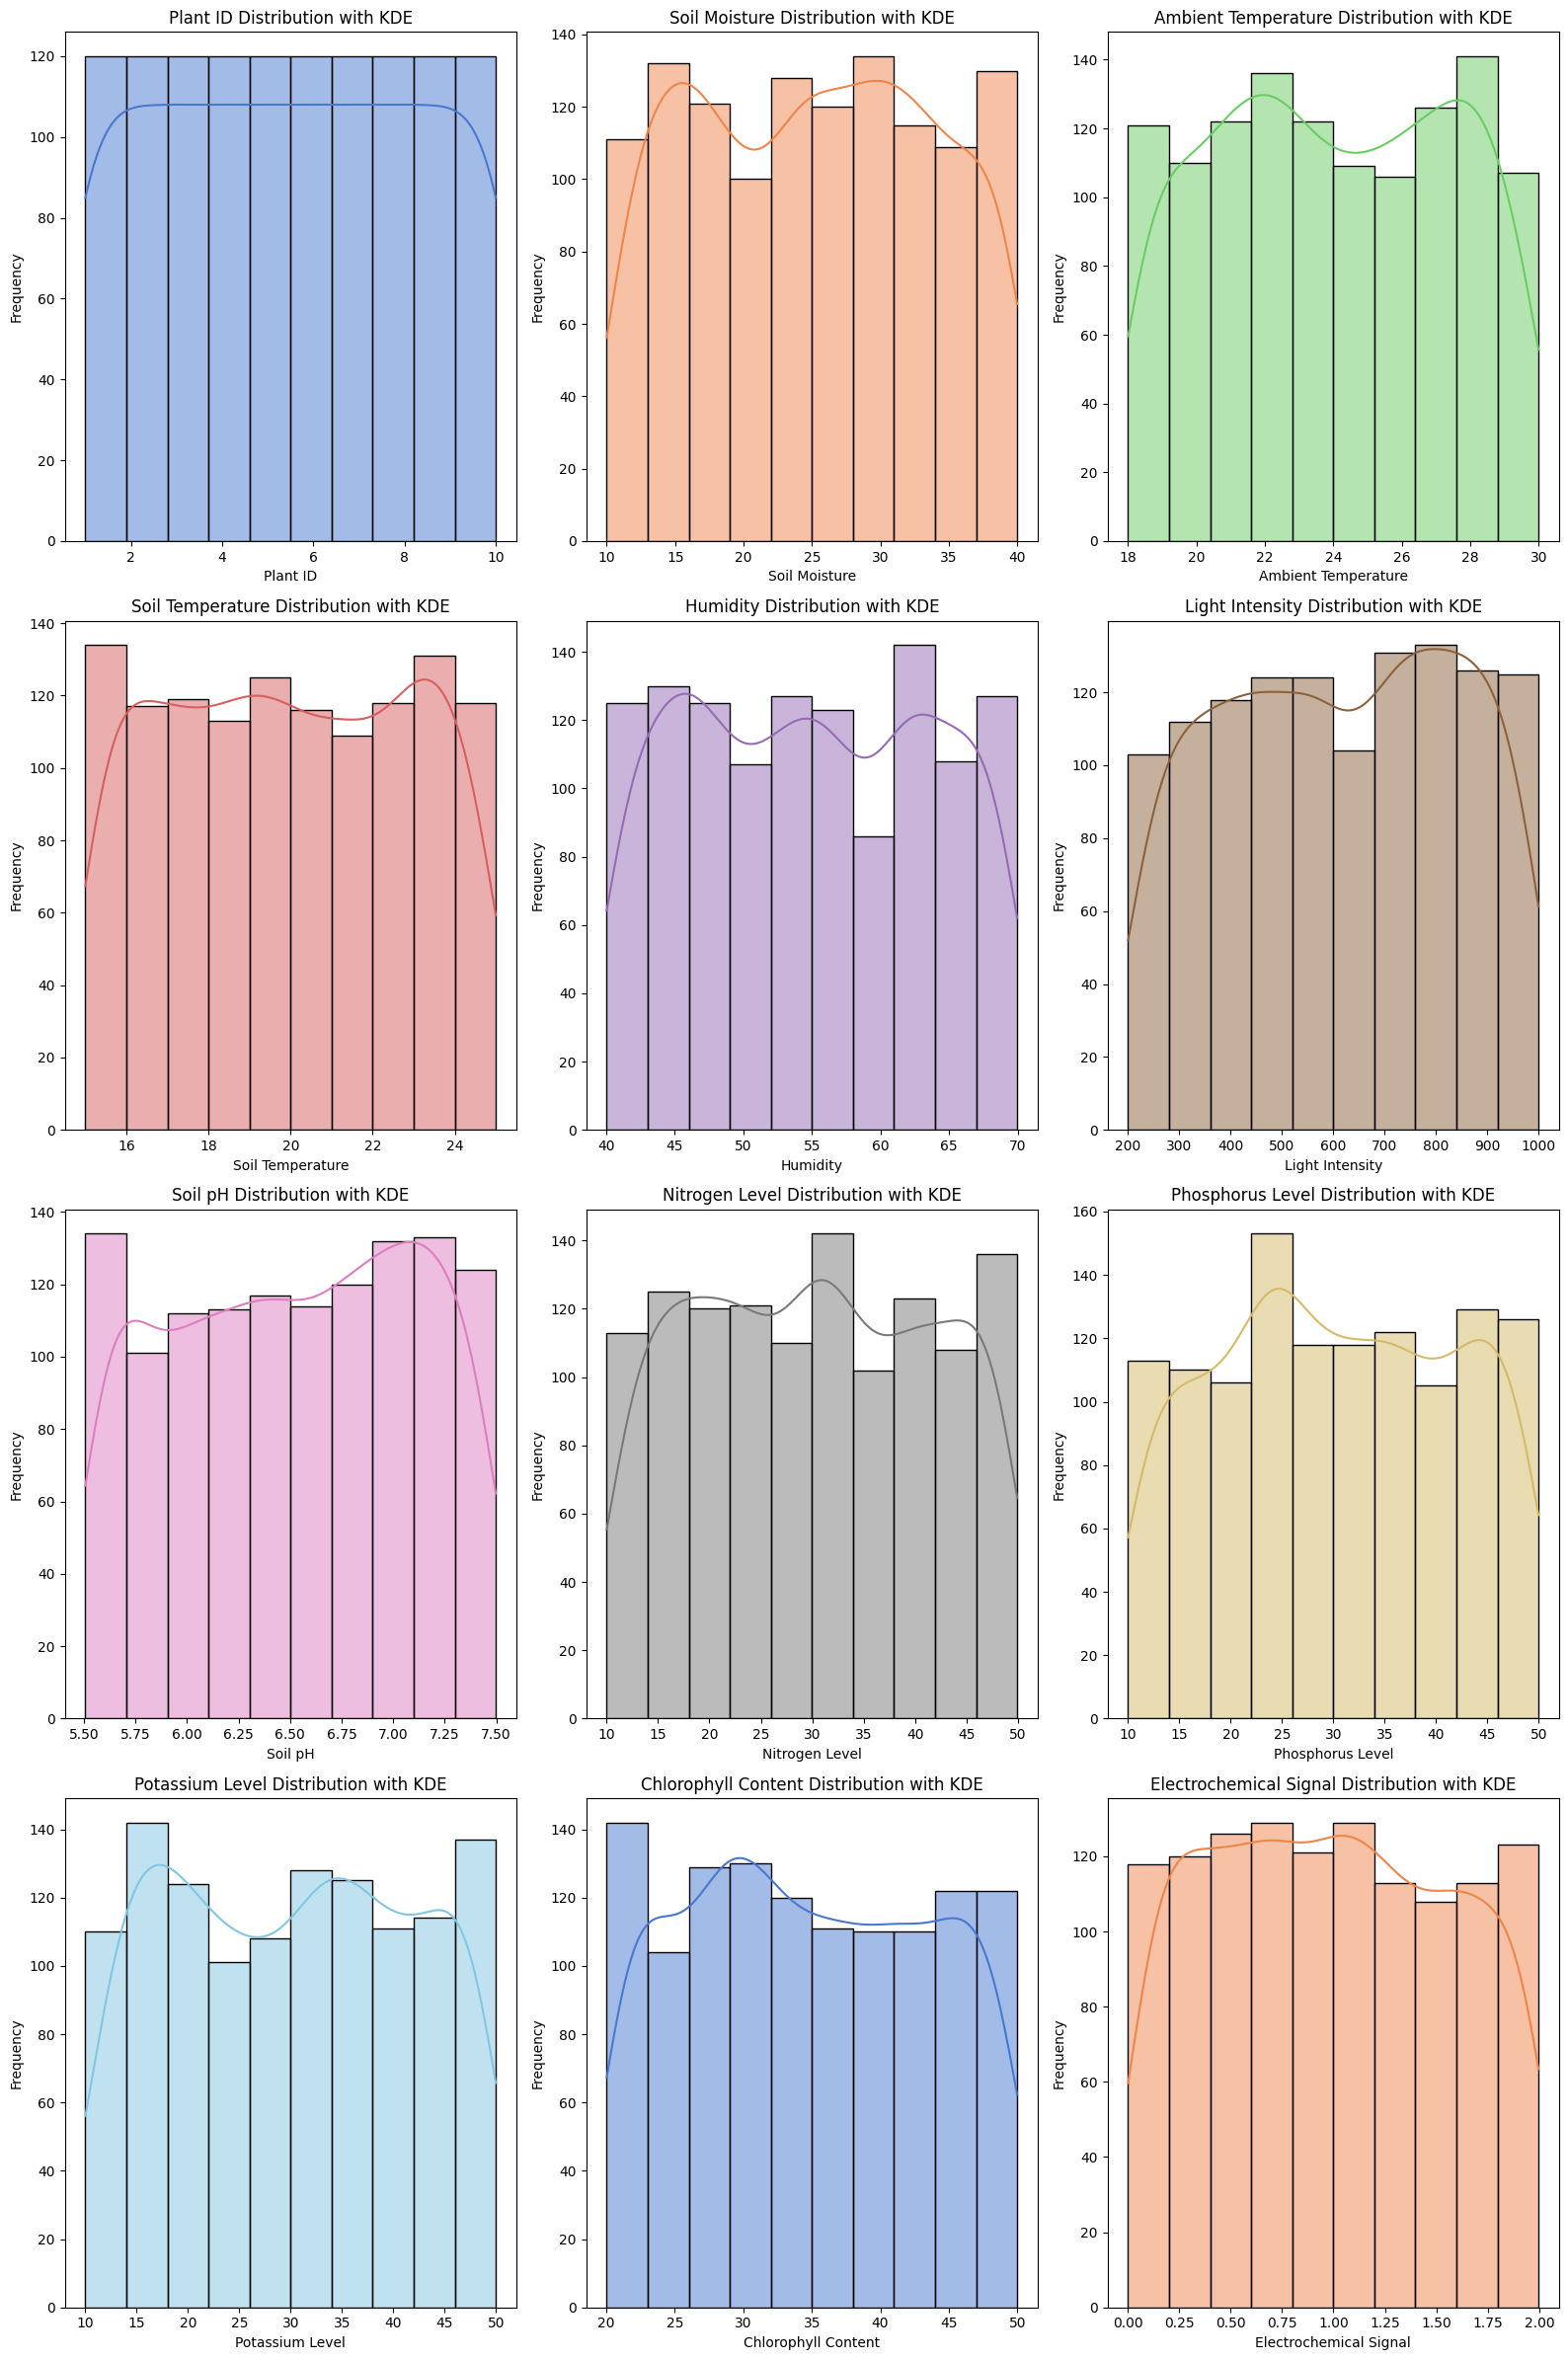

In [10]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(16, 24))  # Adjusted to accommodate more plots
    
    muted_colors = sns.color_palette("muted", len(columns))
    
    for i, column in enumerate(columns):
        plt.subplot(4, 3, i + 1)  
        sns.histplot(data[column], kde=True, bins=10, color=muted_colors[i])
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

columns_to_analyze = [
    'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 
    'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 
    'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 
    'Electrochemical_Signal'
]

# Perform univariate analysis
univariate_analysis(df, columns_to_analyze)

In [11]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=[np.number])

# Calculate skewness and kurtosis
skewness = numerical_df.skew()
kurtosis = numerical_df.kurt()

display("Skewness:", skewness)
print("\n")
display("Kurtosis:", kurtosis)

'Skewness:'

Plant_ID                  0.000000
Soil_Moisture             0.000928
Ambient_Temperature      -0.006935
Soil_Temperature          0.001161
Humidity                  0.021868
Light_Intensity          -0.064399
Soil_pH                  -0.084956
Nitrogen_Level            0.022234
Phosphorus_Level          0.001355
Potassium_Level           0.009818
Chlorophyll_Content       0.052388
Electrochemical_Signal    0.058807
dtype: float64

'Kurtosis:'

Plant_ID                 -1.224342
Soil_Moisture            -1.196111
Ambient_Temperature      -1.201252
Soil_Temperature         -1.228875
Humidity                 -1.238451
Light_Intensity          -1.195560
Soil_pH                  -1.215888
Nitrogen_Level           -1.195051
Phosphorus_Level         -1.156631
Potassium_Level          -1.234812
Chlorophyll_Content      -1.197901
Electrochemical_Signal   -1.170058
dtype: float64

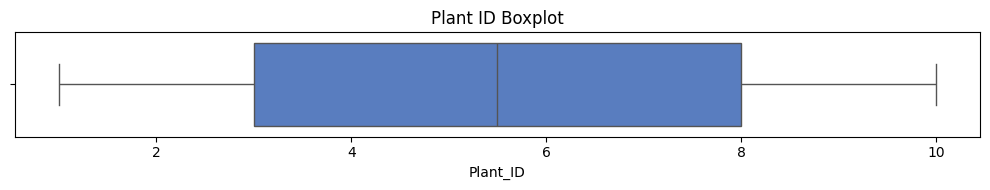


Summary Statistics for Plant ID:
 count    1200.000000
mean        5.500000
std         2.873479
min         1.000000
25%         3.000000
50%         5.500000
75%         8.000000
max        10.000000
Name: Plant_ID, dtype: float64


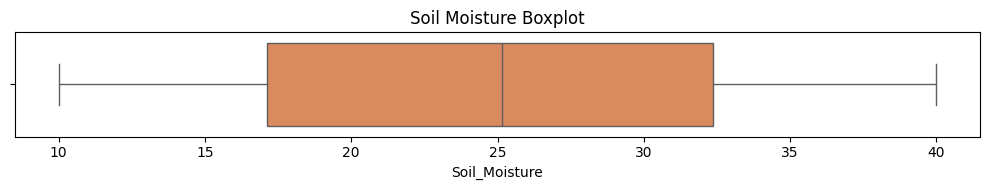


Summary Statistics for Soil Moisture:
 count    1200.000000
mean       25.106918
std         8.677725
min        10.000724
25%        17.131893
50%        25.168333
75%        32.370231
max        39.993164
Name: Soil_Moisture, dtype: float64


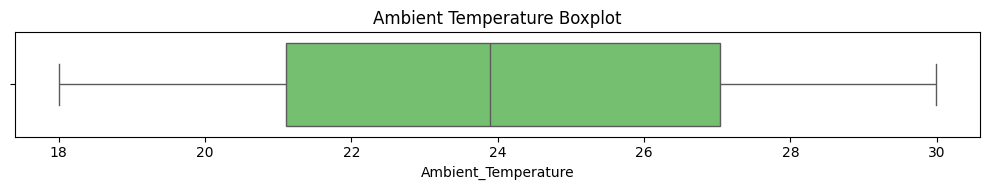


Summary Statistics for Ambient Temperature:
 count    1200.000000
mean       23.999130
std         3.441561
min        18.001993
25%        21.101766
50%        23.889044
75%        27.042634
max        29.990886
Name: Ambient_Temperature, dtype: float64


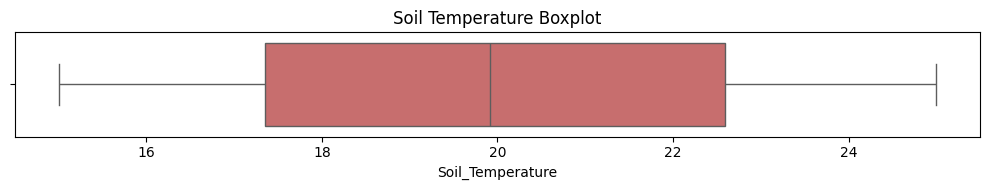


Summary Statistics for Soil Temperature:
 count    1200.000000
mean       19.957794
std         2.932073
min        15.003710
25%        17.353027
50%        19.911473
75%        22.596851
max        24.995929
Name: Soil_Temperature, dtype: float64


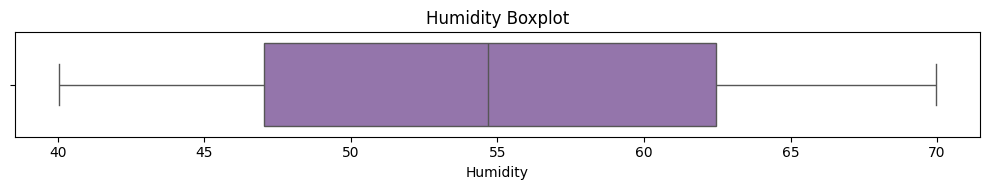


Summary Statistics for Humidity:
 count    1200.000000
mean       54.853165
std         8.784916
min        40.028758
25%        47.019694
50%        54.692069
75%        62.451053
max        69.968871
Name: Humidity, dtype: float64


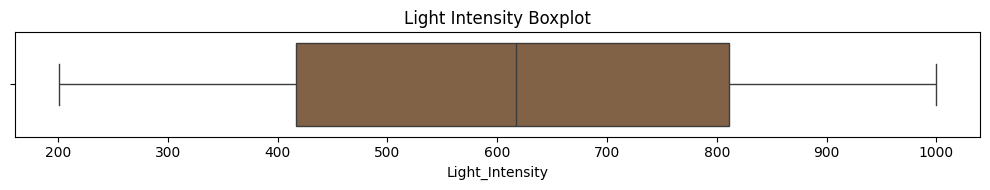


Summary Statistics for Light Intensity:
 count    1200.000000
mean      612.637265
std       228.318853
min       200.615482
25%       416.878983
50%       617.240221
75%       811.474690
max       999.856262
Name: Light_Intensity, dtype: float64


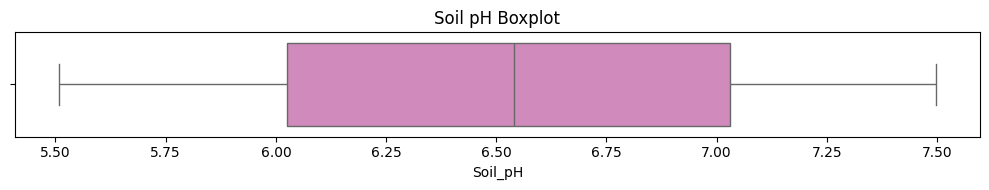


Summary Statistics for Soil pH:
 count    1200.000000
mean        6.524102
std         0.581755
min         5.507392
25%         6.026042
50%         6.540524
75%         7.030039
max         7.497823
Name: Soil_pH, dtype: float64


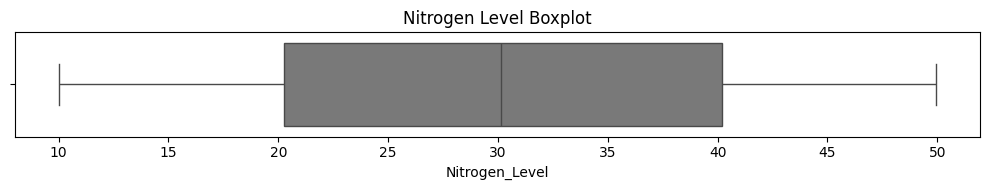


Summary Statistics for Nitrogen Level:
 count    1200.000000
mean       30.106751
std        11.514396
min        10.003650
25%        20.249774
50%        30.138590
75%        40.184737
max        49.951136
Name: Nitrogen_Level, dtype: float64


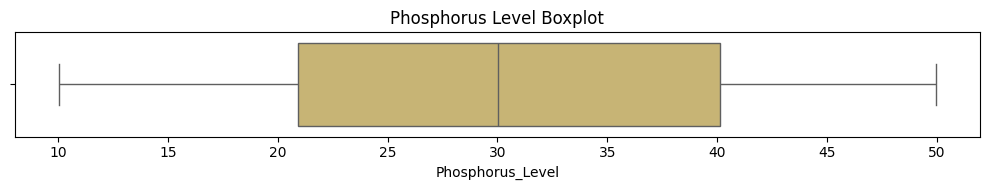


Summary Statistics for Phosphorus Level:
 count    1200.000000
mean       30.264484
std        11.466846
min        10.017690
25%        20.894445
50%        30.019385
75%        40.131459
max        49.980700
Name: Phosphorus_Level, dtype: float64


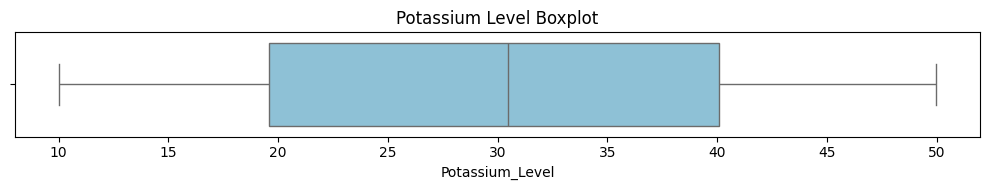


Summary Statistics for Potassium Level:
 count    1200.000000
mean       30.112088
std        11.668085
min        10.000606
25%        19.585561
50%        30.495054
75%        40.108296
max        49.981945
Name: Potassium_Level, dtype: float64


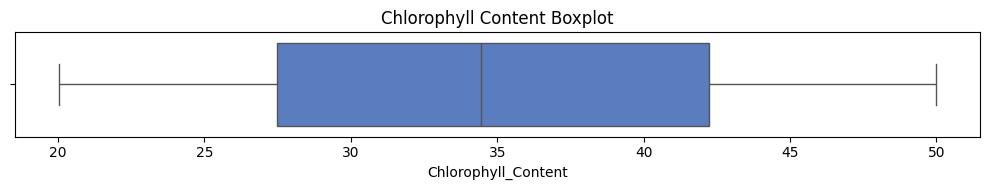


Summary Statistics for Chlorophyll Content:
 count    1200.000000
mean       34.749591
std         8.766995
min        20.025511
25%        27.463350
50%        34.433427
75%        42.232637
max        49.990811
Name: Chlorophyll_Content, dtype: float64


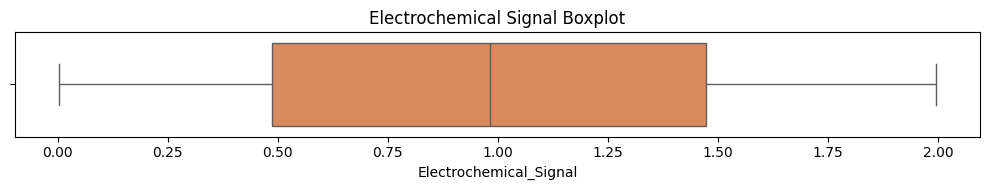


Summary Statistics for Electrochemical Signal:
 count    1200.000000
mean        0.987764
std         0.575116
min         0.002376
25%         0.487982
50%         0.981647
75%         1.473142
max         1.996116
Name: Electrochemical_Signal, dtype: float64


In [12]:
# Function to perform univariate analysis for numeric columns with boxplots and statistics
def univariate_analysis(data, column, title):
    plt.figure(figsize=(10, 2))
    
    color = sns.color_palette("muted")[columns_to_analyze.index(column) % len(sns.color_palette("muted"))]
    
    sns.boxplot(x=data[column], color=color)
    plt.title(f'{title} Boxplot')
    
    plt.tight_layout()
    plt.show()

    print(f'\nSummary Statistics for {title}:\n', data[column].describe())

columns_to_analyze = [
    'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 
    'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 
    'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 
    'Electrochemical_Signal'
]

# Iterate through columns and perform univariate analysis
for column in columns_to_analyze:
    univariate_analysis(df, column, column.replace('_', ' '))

In [13]:
# Convert the Timestamp column to datetime format if not already
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Create a 'Week' column to group by week
df['Week'] = df['Timestamp'].dt.to_period('W').apply(lambda r: r.start_time)

# Aggregate Plant Health Status weekly for each Plant ID
weekly_health_status = (
    df.groupby(['Plant_ID', 'Week', 'Plant_Health_Status'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

weekly_health_status.columns.name = None
weekly_health_status = weekly_health_status.rename(columns={
    'High Stress': 'High_Stress_Count',
    'Moderate Stress': 'Moderate_Stress_Count',
    'Healthy': 'Healthy_Count'
})

weekly_health_status

,Plant_ID,Week,Healthy_Count,High_Stress_Count,Moderate_Stress_Count
0,1,2024-09-30,1,9,5
1,1,2024-10-07,10,12,6
2,1,2024-10-14,2,15,11
3,1,2024-10-21,4,8,16
4,1,2024-10-28,7,6,8
5,2,2024-09-30,2,7,6
6,2,2024-10-07,12,10,6
7,2,2024-10-14,7,12,9
8,2,2024-10-21,9,13,6
9,2,2024-10-28,6,11,4


C:\Users\salja\AppData\Local\Temp\ipykernel_14388\3816405768.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_Health_Status', y=feature, data=df, palette='muted')
C:\Users\salja\AppData\Local\Temp\ipykernel_14388\3816405768.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_Health_Status', y=feature, data=df, palette='muted')
C:\Users\salja\AppData\Local\Temp\ipykernel_14388\3816405768.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Plant_Health_Status', y=feature, data=df, palette='muted')
C:\Users\salja\AppD

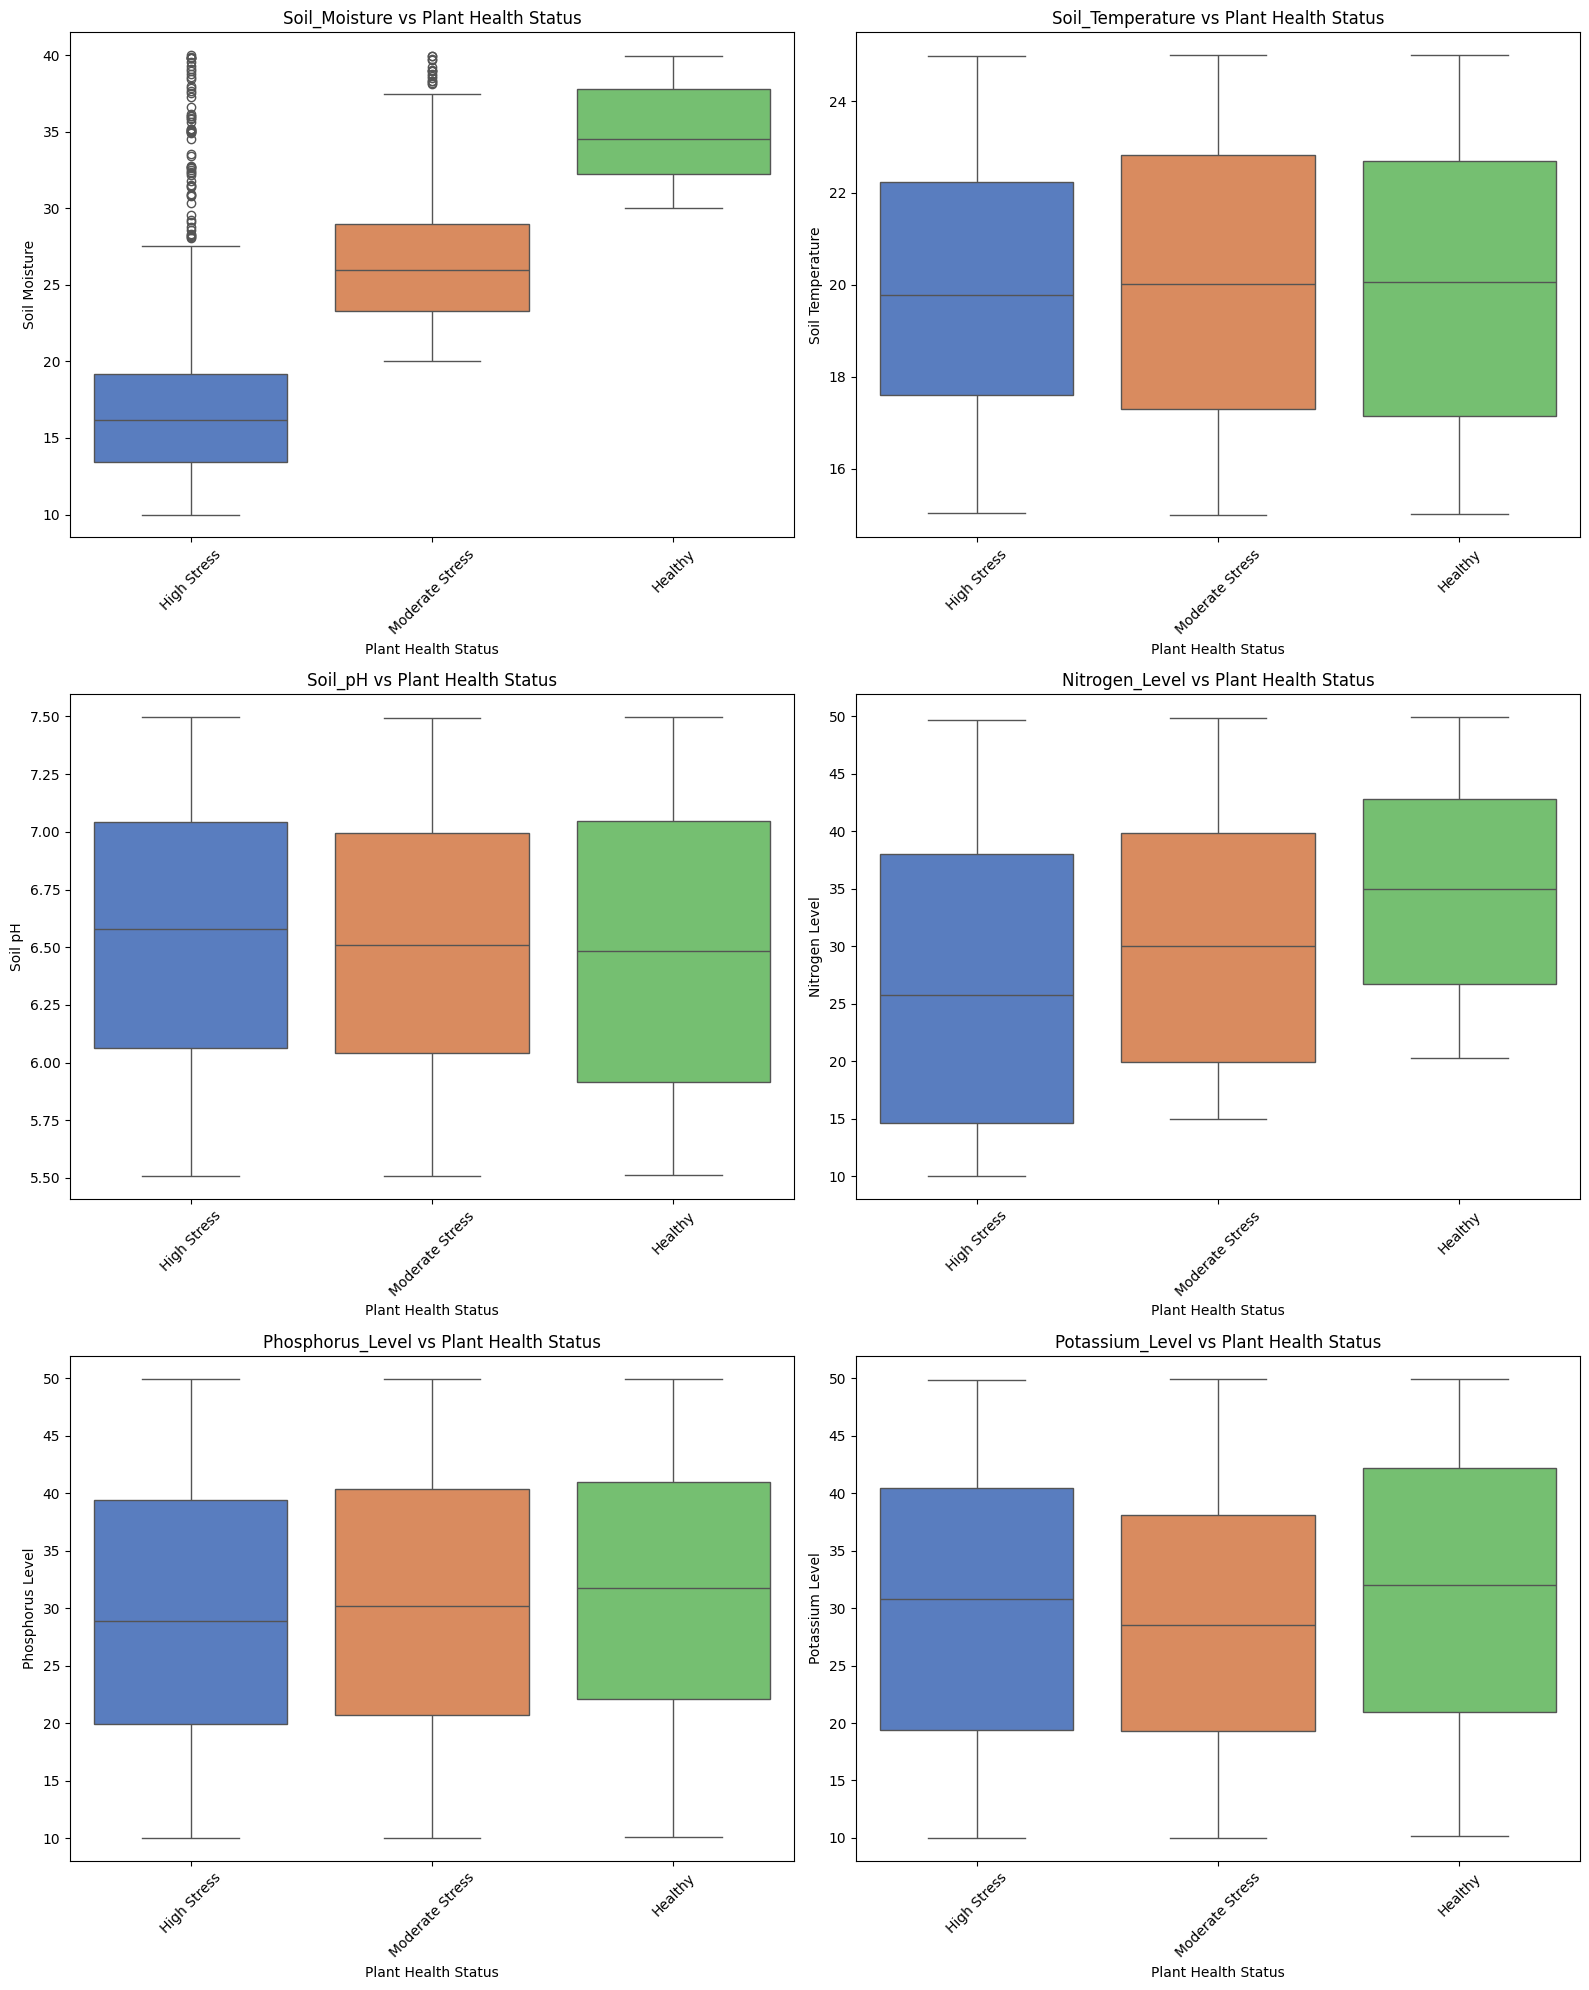

In [14]:
# Compare Plant_Health_Status with Soil Properties
# Define soil properties
soil_properties = [
    'Soil_Moisture', 'Soil_Temperature', 'Soil_pH', 
    'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level'
]

# Create subplots to visualize the relationship between Plant_Health_Status and soil properties
plt.figure(figsize=(16, 20))
for i, feature in enumerate(soil_properties):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='Plant_Health_Status', y=feature, data=df, palette='muted')
    plt.title(f'{feature} vs Plant Health Status')
    plt.xlabel('Plant Health Status')
    plt.ylabel(feature.replace('_', ' '))
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
Numerical_Columns = ['Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']
Categorical_Columns = ['Timestamp', 'Plant_Health_Status']

In [26]:
custom_mapping = {'High Stress': 2, 'Moderate Stress': 1, 'Healthy': 0}


In [27]:
df['Plant_Health_Status_Encoded'] = df['Plant_Health_Status'].map(custom_mapping)


In [35]:
features_to_keep = ['Soil_Moisture','Ambient_Temperature','Humidity','Light_Intensity','Plant_Health_Status_Encoded']

In [36]:
df_subset = df[features_to_keep]
df_subset.head()

,Soil_Moisture,Ambient_Temperature,Humidity,Light_Intensity,Plant_Health_Status_Encoded
0,27.521109,22.240245,55.291904,556.172805,2
1,14.835566,21.706763,63.949181,596.136721,2
2,17.086362,21.180946,67.837956,591.124627,2
3,15.336156,22.593302,58.190811,241.412476,2
4,39.822216,28.929001,63.772036,444.493830,2


In [37]:
# Define features and target
X = df_subset.drop(columns=['Plant_Health_Status_Encoded'])  # Features
y = df_subset['Plant_Health_Status_Encoded']  # Target

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the shapes of the splits for verification
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (960, 4)
X_test Shape: (240, 4)
y_train Shape: (960,)
y_test Shape: (240,)


In [39]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
# Initialize models
models = {
    "KNN Classifier": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Display model names to confirm initialization
print("Models initialized:", list(models.keys()))

Models initialized: ['KNN Classifier', 'Decision Tree', 'Random Forest', 'Gradient Boosting']



Model: KNN Classifier
Accuracy: 0.75
AUC: 0.87


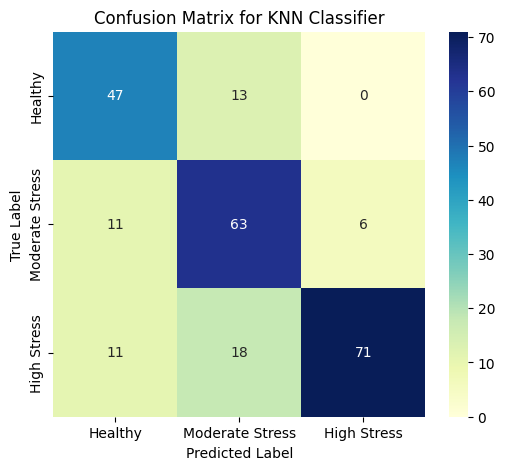

                 precision    recall  f1-score   support

        Healthy       0.68      0.78      0.73        60
Moderate Stress       0.67      0.79      0.72        80
    High Stress       0.92      0.71      0.80       100

       accuracy                           0.75       240
      macro avg       0.76      0.76      0.75       240
   weighted avg       0.78      0.75      0.76       240


Model: Decision Tree
Accuracy: 0.75
AUC: 0.81


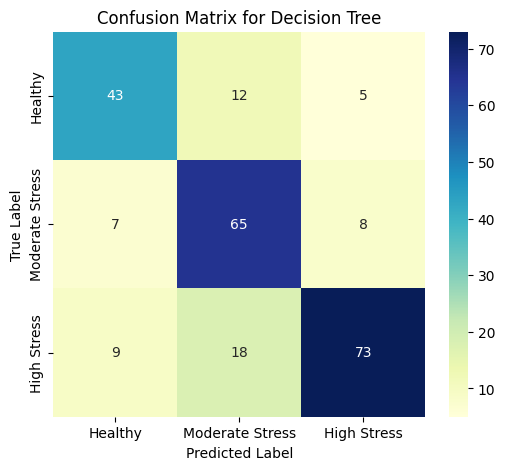

                 precision    recall  f1-score   support

        Healthy       0.73      0.72      0.72        60
Moderate Stress       0.68      0.81      0.74        80
    High Stress       0.85      0.73      0.78       100

       accuracy                           0.75       240
      macro avg       0.75      0.75      0.75       240
   weighted avg       0.76      0.75      0.76       240


Model: Random Forest
Accuracy: 0.85
AUC: 0.90


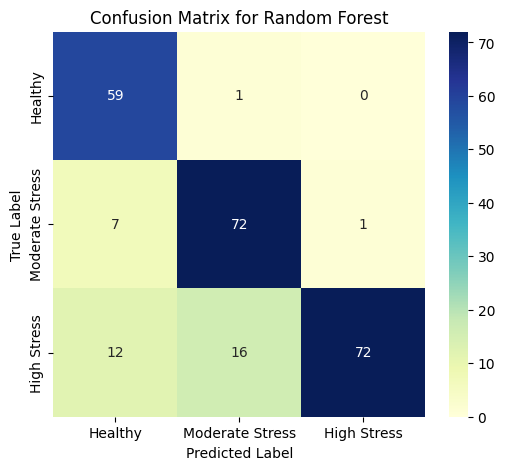

                 precision    recall  f1-score   support

        Healthy       0.76      0.98      0.86        60
Moderate Stress       0.81      0.90      0.85        80
    High Stress       0.99      0.72      0.83       100

       accuracy                           0.85       240
      macro avg       0.85      0.87      0.85       240
   weighted avg       0.87      0.85      0.84       240


Model: Gradient Boosting
Accuracy: 0.84
AUC: 0.90


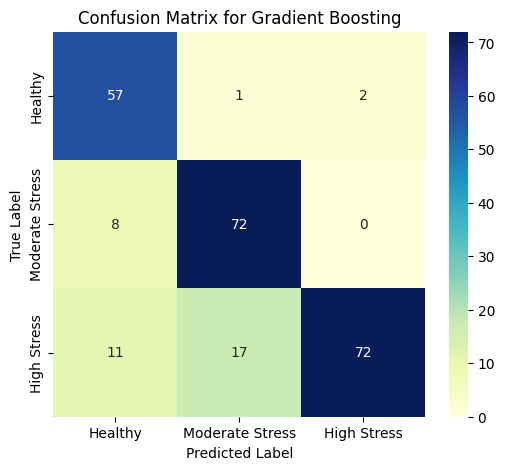

                 precision    recall  f1-score   support

        Healthy       0.75      0.95      0.84        60
Moderate Stress       0.80      0.90      0.85        80
    High Stress       0.97      0.72      0.83       100

       accuracy                           0.84       240
      macro avg       0.84      0.86      0.84       240
   weighted avg       0.86      0.84      0.84       240



In [41]:
# Initialize lists to store results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Calculate AUC
    if hasattr(model, "predict_proba"):  
        y_prob = model.predict_proba(X_test_scaled)
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    else:
        auc = None  
    
    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "Classification Report": classification_report(y_test, y_pred, target_names=['Healthy', 'Moderate Stress', 'High Stress'])
    })

# Display results for each model
for result in results:
    print(f"\nModel: {result['Model']}")
    print(f"Accuracy: {result['Accuracy']:.2f}")
    if result["AUC"] is not None:
        print(f"AUC: {result['AUC']:.2f}")
    
    # Confusion Matrix Visualization
    cm = result["Confusion Matrix"]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Healthy', 'Moderate Stress', 'High Stress'], 
                yticklabels=['Healthy', 'Moderate Stress', 'High Stress'])
    plt.title(f'Confusion Matrix for {result["Model"]}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Print Classification Report
    print(result["Classification Report"])

In [43]:
df_subset.head()

,Soil_Moisture,Ambient_Temperature,Humidity,Light_Intensity,Plant_Health_Status_Encoded
0,27.521109,22.240245,55.291904,556.172805,2
1,14.835566,21.706763,63.949181,596.136721,2
2,17.086362,21.180946,67.837956,591.124627,2
3,15.336156,22.593302,58.190811,241.412476,2
4,39.822216,28.929001,63.772036,444.493830,2


In [42]:
df_subset.columns

Index(['Soil_Moisture', 'Ambient_Temperature', 'Humidity', 'Light_Intensity',
       'Plant_Health_Status_Encoded'],
      dtype='object')

In [176]:
new_data = pd.DataFrame({
    "Soil_Moisture": [35],
    "Ambient_Temperature": [28.50],
    "Humidity": [35],
    "Light_Intensity": [400]
})

In [177]:
new_data_scaled = scaler.transform(new_data)


In [178]:
for model_name, model in models.items():
    prediction = model.predict(new_data_scaled)
    print("According to ", model, " model,")
    print("outcome is ", prediction)

According to  KNeighborsClassifier()  model,
outcome is  [1]
According to  DecisionTreeClassifier(random_state=42)  model,
outcome is  [0]
According to  RandomForestClassifier(random_state=42)  model,
outcome is  [0]
According to  GradientBoostingClassifier(random_state=42)  model,
outcome is  [0]
